# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [2]:
import re
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')



## 2. Datos

In [3]:
df_kaggle = pd.read_csv('./data/train.csv', encoding='latin-1')
df = df_kaggle.copy()

### 2.1 Exploración de los datos

In [4]:
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

Shape: (912, 13)
Columnas: ['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_in_euros']


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 92.8 KB


In [6]:
print("Nulos por columna:")
print(df.isnull().sum())

print(f"\nTarget (Price_in_euros):")
print(df['Price_in_euros'].describe().round(2))

Nulos por columna:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64

Target (Price_in_euros):
count     912.00
mean     1111.72
std       687.96
min       174.00
25%       589.00
50%       978.00
75%      1483.94
max      6099.00
Name: Price_in_euros, dtype: float64


In [7]:
for col in ['TypeName','Company','OpSys']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


TypeName:
TypeName
Notebook              509
Gaming                143
Ultrabook             141
2 in 1 Convertible     80
Workstation            20
Netbook                19

Company:
Company
Lenovo       202
Dell         197
HP           194
Asus         121
Acer          74
MSI           37
Toshiba       34
Apple         17
Razer          6
Mediacom       6
Samsung        5
Microsoft      5
Xiaomi         3
Chuwi          2
Huawei         2
Google         2
Vero           2
Fujitsu        2
LG             1

OpSys:
OpSys
Windows 10      741
Linux            48
No OS            44
Windows 7        29
Chrome OS        24
macOS            11
Windows 10 S      7
Mac OS X          6
Android           2


Las columnas **Ram**, **Weight**, **ScreenResolution**, **Cpu**, **Gpu** y **Memory** contienen info necesaria en string, que hay q convertir.

| *Columna original* | *Features extraídas* |
|---|---|
| **Ram** | **Ram_GB** (int) |
| **Weight** | **Weight_kg** (float) |
| **ScreenResolution** | **IPS**, **Touchscreen**, **Res_W**, **Res_H**, **PPI** |
| **Cpu** | **Cpu_brand**, **Cpu_type**, **Cpu_GHz** |
| **Gpu** | **Gpu_brand** |
| **Memory** | **SSD_GB**, **HDD_GB**, **Flash_GB**, **Total_storage**, **Has_SSD**, **Has_HDD**, **Has_Both** |

In [8]:
def engineer_features(df):
    """
    Aplica todo el feature engineering.
    Diseñada para usarse igual en train y en test (sin fit).
    """

    # Ram: "8GB" → 8
    df['Ram_GB'] = df['Ram'].str.replace('GB', '').astype(int)

    # Weight: "2.2kg" → 2.2
    df['Weight_kg'] = df['Weight'].str.replace('kg', '', case=False).astype(float)

    # ScreenResolution: flags + resolución + PPI
    df['IPS']         = df['ScreenResolution'].str.contains('IPS').astype(int)
    df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen|Touch').astype(int)
    res               = df['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')
    df['Res_W']       = res[0].astype(float)
    df['Res_H']       = res[1].astype(float)
    df['PPI']         = np.sqrt(df['Res_W']**2 + df['Res_H']**2) / df['Inches']

    # CPU: marca, tipo de core, velocidad
    df['Cpu_brand'] = df['Cpu'].apply(
        lambda x: 'Intel' if 'Intel' in str(x) else ('AMD' if 'AMD' in str(x) else 'Other'))
    df['Cpu_type'] = df['Cpu'].apply(lambda x:
        'i9' if 'i9' in str(x) else ('i7' if 'i7' in str(x) else
        ('i5' if 'i5' in str(x) else ('i3' if 'i3' in str(x) else
        ('Ryzen' if 'Ryzen' in str(x) else ('Celeron' if 'Celeron' in str(x) else
        ('Xeon' if 'Xeon' in str(x) else 'Other')))))))
    df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)

    # GPU: marca
    df['Gpu_brand'] = df['Gpu'].apply(
        lambda x: 'Nvidia' if 'Nvidia' in str(x) else ('Intel' if 'Intel' in str(x) else
        ('AMD' if 'AMD' in str(x) else 'Other')))

    # Memory: extraer GB de SSD/HDD/Flash
    def parse_memory(mem_str):
        ssd, hdd, flash = 0, 0, 0
        for part in str(mem_str).replace('+', '|').split('|'):
            part = part.strip()
            matches = re.findall(r'[\d.]+', part)
            val = float(matches[0]) * (1024 if 'TB' in part else 1) if matches else 0
            if   'SSD'   in part:  ssd   += val
            elif 'HDD'   in part:  hdd   += val
            elif 'Flash' in part or 'eMMC' in part:  flash += val
        return pd.Series({'SSD_GB': ssd, 'HDD_GB': hdd, 'Flash_GB': flash})

    mem_df = df['Memory'].apply(parse_memory)
    df = pd.concat([df, mem_df], axis=1)
    df['Total_storage'] = df['SSD_GB'] + df['HDD_GB'] + df['Flash_GB']
    df['Has_SSD']  = (df['SSD_GB'] > 0).astype(int)
    df['Has_HDD']  = (df['HDD_GB'] > 0).astype(int)
    df['Has_Both'] = ((df['SSD_GB'] > 0) & (df['HDD_GB'] > 0)).astype(int)

    # Encoding categóricas
    for col in ['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_type', 'Gpu_brand']:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

    return df

FEATURES = [
    'Company_enc', 'TypeName_enc', 'Inches', 'Ram_GB', 'Weight_kg',
    'IPS', 'Touchscreen', 'Res_W', 'Res_H', 'PPI',
    'Cpu_brand_enc', 'Cpu_type_enc', 'Cpu_GHz',
    'Gpu_brand_enc',
    'SSD_GB', 'HDD_GB', 'Flash_GB', 'Total_storage', 'Has_SSD', 'Has_HDD', 'Has_Both',
    'OpSys_enc',
]

df_fe = engineer_features(df)
print(f"Features finales: {len(FEATURES)}")
print(f"Nulos tras FE: {df_fe[FEATURES].isnull().sum().sum()}")
df_fe[FEATURES].head()

Features finales: 22
Nulos tras FE: 0


,Company_enc,TypeName_enc,Inches,Ram_GB,Weight_kg,IPS,Touchscreen,Res_W,Res_H,PPI,...,Cpu_GHz,Gpu_brand_enc,SSD_GB,HDD_GB,Flash_GB,Total_storage,Has_SSD,Has_HDD,Has_Both,OpSys_enc
0,7,3,15.6,8,1.86,0,0,1920.0,1080.0,141.211998,...,2.0,1,256.0,0.0,0.0,256.0,1,0,0,5
1,4,1,15.6,16,2.59,0,0,1920.0,1080.0,141.211998,...,2.6,2,0.0,1024.0,0.0,1024.0,0,1,0,5
2,7,3,15.6,8,2.04,0,0,1920.0,1080.0,141.211998,...,2.7,2,0.0,1024.0,0.0,1024.0,0,1,0,5
3,1,4,13.3,8,1.34,0,0,1440.0,900.0,127.677940,...,1.8,1,0.0,0.0,128.0,128.0,0,0,0,8
4,4,3,15.6,4,2.25,0,0,1920.0,1080.0,141.211998,...,2.0,0,0.0,1024.0,0.0,1024.0,0,1,0,2


### 2.2 Definir X e y


In [9]:
X = df_fe[FEATURES]
y = df_fe['Price_in_euros']
print(f"X: {X.shape}  |  y: {y.shape}")


X: (912, 22)  |  y: (912,)


### 2.3 Dividir en train y test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (729, 22) | Test: (183, 22)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [11]:
# Verificación rápida: no nulos, no escalado necesario
print("Nulos X_train:", X_train.isnull().sum().sum())
print("Rango Ram_GB:", X_train['Ram_GB'].min(), "-", X_train['Ram_GB'].max())


Nulos X_train: 0
Rango Ram_GB: 2 - 64


## 4. Modelado

### 4.1 Entrenamiento

In [12]:
model = lgb.LGBMRegressor(
    n_estimators    = 800,
    learning_rate   = 0.03,
    num_leaves      = 63,
    min_child_samples = 10,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbose         = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

print("Modelo entrenado.")

Modelo entrenado.


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [13]:
y_pred_val = model.predict(X_test)
rmse_val   = root_mean_squared_error(y_test, y_pred_val)
print(f"RMSE en validación: {rmse_val:.2f} €")

RMSE en validación: 284.34 €


### 4.3 Optimización (up to you 🫰🏻)

- Feature importanece [fi]

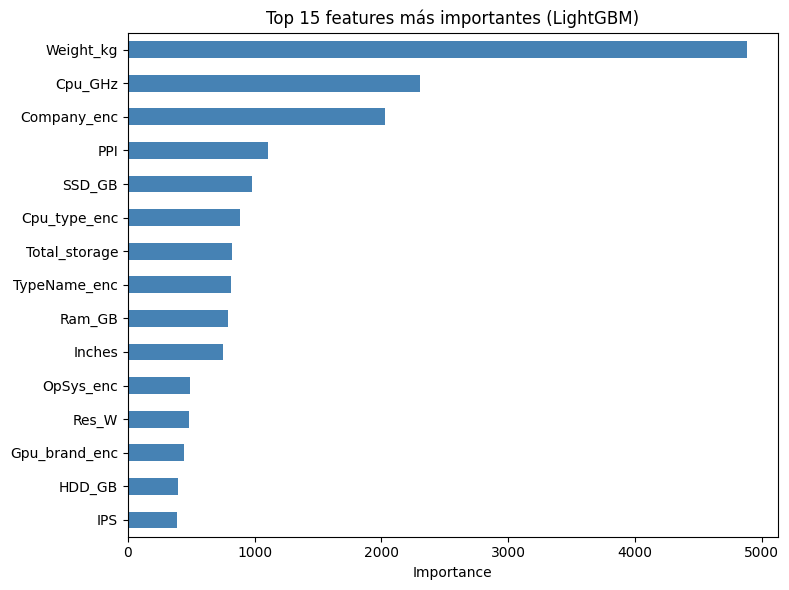

Weight_kg        4882
Cpu_GHz          2307
Company_enc      2027
PPI              1108
SSD_GB            981
Cpu_type_enc      881
Total_storage     823
TypeName_enc      811
Ram_GB            792
Inches            749


In [14]:
fi = (pd.Series(model.feature_importances_, index=FEATURES)
       .sort_values(ascending=False))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
fi.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 features más importantes (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(fi.head(10).to_string())


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [15]:
final_model = lgb.LGBMRegressor(
    n_estimators    = 800,
    learning_rate   = 0.03,
    num_leaves      = 63,
    min_child_samples = 10,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbose         = -1,
)

final_model.fit(X, y)
print(f"Modelo final entrenado sobre {X.shape[0]} muestras.")

Modelo final entrenado sobre 912 muestras.


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [16]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [17]:
X_pred_fe = engineer_features(X_pred)
X_pred_final = X_pred_fe[FEATURES]

print(f"Shape test procesado: {X_pred_final.shape}")
print(f"Nulos: {X_pred_final.isnull().sum().sum()}")
X_pred_final.head()

Shape test procesado: (391, 22)
Nulos: 0


,Company_enc,TypeName_enc,Inches,Ram_GB,Weight_kg,IPS,Touchscreen,Res_W,Res_H,PPI,...,Cpu_GHz,Gpu_brand_enc,SSD_GB,HDD_GB,Flash_GB,Total_storage,Has_SSD,Has_HDD,Has_Both,OpSys_enc
0,9,1,15.6,16,2.400,0,0,1920.0,1080.0,141.211998,...,2.8,2,512.0,0.0,0.0,512.0,1,0,0,3
1,0,3,15.6,4,2.400,0,0,1366.0,768.0,100.454670,...,1.6,1,0.0,500.0,0.0,500.0,0,1,0,1
2,9,3,15.6,4,1.900,0,0,1366.0,768.0,100.454670,...,2.0,1,0.0,1024.0,0.0,1024.0,0,1,0,3
3,4,0,15.6,8,2.191,1,1,1920.0,1080.0,141.211998,...,2.5,1,256.0,0.0,0.0,256.0,1,0,0,4
4,7,3,14.0,4,1.950,0,0,1920.0,1080.0,157.350512,...,2.5,1,256.0,0.0,0.0,256.0,1,0,0,4


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [18]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [19]:
predictions = final_model.predict(X_pred_final)

submission = pd.DataFrame({
    'laptop_ID':      X_pred['laptop_ID'],
    'Price_in_euros': predictions,
})

print(f"Shape: {submission.shape}")
print(f"Precio medio predicho: {predictions.mean():.2f}€")
submission.head()

Shape: (391, 2)
Precio medio predicho: 1040.76€


,laptop_ID,Price_in_euros
0,209,1302.488594
1,1281,297.194038
2,1168,405.897127
3,1231,831.727211
4,1020,874.234094


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [20]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [21]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260627_213123.csv'. ¡A Kaggle!
